In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os



import os

# Determina la cartella di partenza
try:
    BASE_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    BASE_DIR = os.getcwd()

# PROVA 1: 'datas' è nella cartella corrente
path1 = os.path.join(BASE_DIR, "datas")
# PROVA 2: 'datas' è una cartella sopra (comune se sei in /src)
path2 = os.path.join(BASE_DIR, "..", "datas")

if os.path.exists(path1):
    data_path = path1
elif os.path.exists(path2):
    data_path = path2
else:
    # Se non la trova, usa il percorso assoluto che abbiamo visto prima
    data_path = r"C:\Users\rober\OneDrive\Desktop\solar-flare-predictor-main\solar-flare-predictor-main\datas"

print(f"📂 Cartella dati impostata su: {os.path.abspath(data_path)}")

file_euv  = os.path.join(data_path, "euvs-7-day.json")
file_sfp  = os.path.join(data_path, "sfp_dataset.csv")
file_bg   = os.path.join(data_path, "xray-background-7-day.json")
file_xray = os.path.join(data_path, "xrays-7-day.json")

# --- CARICAMENTO DATI ---
try:
    # 1. EUV (Estremo Ultravioletto)
    df_euv = pd.read_json(file_euv)

    # 2. Dataset preprocessato per il modello (SFP)
    df_sfp = pd.read_csv(file_sfp)

    # 3. Background X-ray (Baseline giornaliera)
    df_bg = pd.read_json(file_bg)

    # 4. Flusso X-ray (Dati ad alta risoluzione 7 giorni)
    df_xray = pd.read_json(file_xray)

    # Conversione dei time_tag in formati datetime per tutti i dataframe
    for df in [df_euv, df_sfp, df_bg, df_xray]:
        if 'time_tag' in df.columns:
            df['time_tag'] = pd.to_datetime(df['time_tag'])
            
    print("✅ Tutti i dataset sono stati caricati correttamente dalla cartella 'datas/'.")

except FileNotFoundError as e:
    print(f"❌ Errore: Non ho trovato uno dei file. Controlla che la cartella contenga i file corretti.")
    print(f"Dettaglio errore: {e}")

📂 Cartella dati impostata su: c:\Users\rober\OneDrive\Desktop\solar-flare-predictor-main\solar-flare-predictor-main\datas
✅ Tutti i dataset sono stati caricati correttamente dalla cartella 'datas/'.


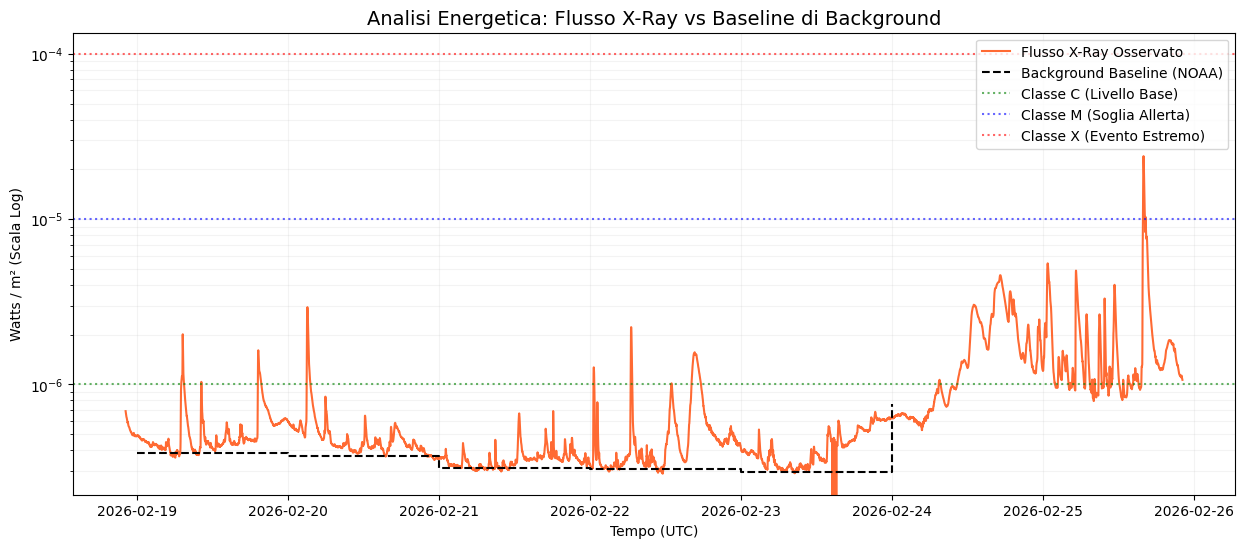

In [ ]:

import matplotlib.pyplot as plt
import numpy as np

def plot_solar_activity(df_xray, df_bg):
    # <-- Nota questo spazio (indentazione)
    plt.figure(figsize=(15, 6))
    
    # 1. Plot del flusso X-Ray Osservato
    if '0.1-0.8nm' in df_xray.columns:
        x_val = df_xray.index
        y_val = df_xray['0.1-0.8nm']
    elif 'energy' in df_xray.columns:
        df_plot = df_xray[df_xray['energy'] == '0.1-0.8nm']
        x_val = df_plot['time_tag']
        y_val = df_plot['observed_flux']
    else:
        x_val = df_xray['time_tag']
        y_val = df_xray.iloc[:, 1]

    plt.plot(x_val, y_val, label='Flusso X-Ray Osservato', color='orangered', lw=1.5, alpha=0.8)
    
    # 2. Plot del Background
    plt.step(df_bg['time_tag'], df_bg['background'], where='post', 
             label='Background Baseline (NOAA)', color='black', linestyle='--')
    
    # 3. SCALA LOGARITMICA: Essenziale per i flare solari
    plt.yscale('log')
    
    # 4. SOGLIE CLASSI NOAA (Aggiungi queste linee alla presentazione!)
    plt.axhline(y=1e-6, color='green', linestyle=':', alpha=0.6, label='Classe C (Livello Base)')
    plt.axhline(y=1e-5, color='blue', linestyle=':', alpha=0.6, label='Classe M (Soglia Allerta)')
    plt.axhline(y=1e-4, color='red', linestyle=':', alpha=0.6, label='Classe X (Evento Estremo)')
    
    plt.title("Analisi Energetica: Flusso X-Ray vs Baseline di Background", fontsize=14)
    plt.ylabel("Watts / m² (Scala Log)")
    plt.xlabel("Tempo (UTC)")
    plt.legend(loc='upper right')
    plt.grid(True, which="both", ls="-", alpha=0.15)
    plt.show()

# Eseguiamo la funzione (fuori dal blocco def)
plot_solar_activity(df_xray, df_bg)

In questo grafico osserviamo il flusso dei raggi X (canale 0.1-0.8nm) confrontato 
con la baseline del rumore di fondo solare (Background). La scala logaritmica è essenziale 
poiché i brillamenti solari variano di diversi ordini di grandezza. Le linee tratteggiate 
rappresentano le soglie critiche della NOAA (Classi C, M, X). Il modello dovrà imparare a 
riconoscere quando il flusso supera la soglia di 'quiete' magnetica per prevedere l'inizio di 
un evento geo-effettivo.

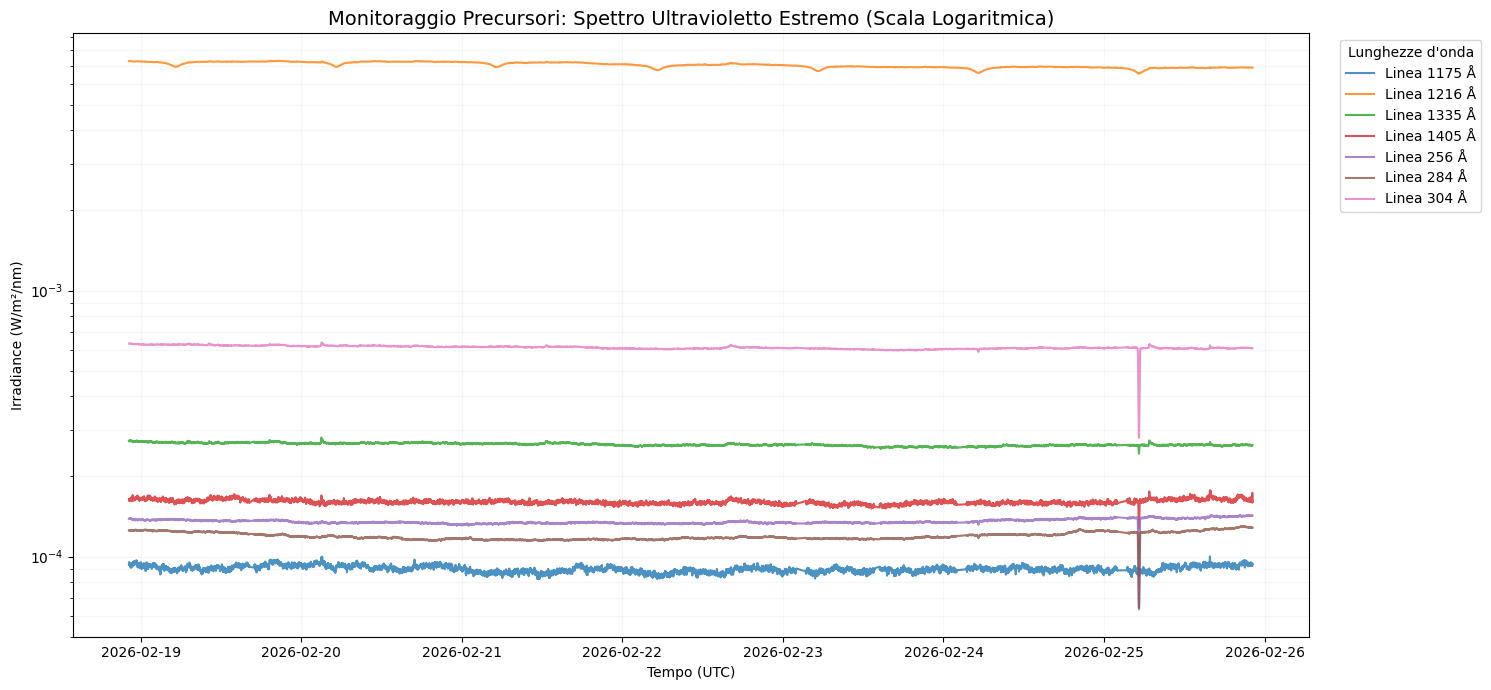

In [ ]:

import matplotlib.pyplot as plt

def plot_uv_precursors(df_euv):
    plt.figure(figsize=(15, 7))
    
    # 1. Preparazione dati (Pivot se necessario)
    if 'line' in df_euv.columns:
        df_uv_pivot = df_euv.pivot_table(index='time_tag', columns='line', values='value')
    else:
        df_uv_pivot = df_euv.copy()
        if 'time_tag' in df_uv_pivot.columns:
            df_uv_pivot = df_uv_pivot.set_index('time_tag')

    # 2. Plot di ogni linea UV
    # Usiamo un ciclo per plottare tutte le colonne UV
    for col in df_uv_pivot.columns:
        if 'euv_' in str(col) or str(col).isdigit(): # Filtra solo colonne dati
            plt.plot(df_uv_pivot.index, df_uv_pivot[col], label=f"Linea {col} Å", alpha=0.8)

    # 3. TRUCCO PER LA PRESENTAZIONE: Scala Logaritmica
    # Questo permette di vedere le variazioni anche se i valori sono piccoli
    plt.yscale('log')
    
    plt.title("Monitoraggio Precursori: Spettro Ultravioletto Estremo (Scala Logaritmica)", fontsize=14)
    plt.ylabel("Irradiance (W/m²/nm)")
    plt.xlabel("Tempo (UTC)")
    
    # Spostiamo la legenda fuori dal grafico per non coprire i dati
    plt.legend(title="Lunghezze d'onda", bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.grid(True, which="both", ls="-", alpha=0.1)
    plt.tight_layout()
    plt.show()

# Esecuzione
plot_uv_precursors(df_euv)

L'ultravioletto estremo (EUV) monitora diversi strati della corona solare. 
A differenza dei raggi X, le variazioni UV sono più sottili ma spesso più costanti. 
Visualizzando i dati in scala logaritmica, isoliamo i piccoli cambiamenti nelle 
diverse lunghezze d'onda (Å). Queste feature fungono da 'contesto' per la rete LSTM, 
fornendo informazioni sullo stato fisico della regione attiva prima che avvenga l'esplosione di raggi X.

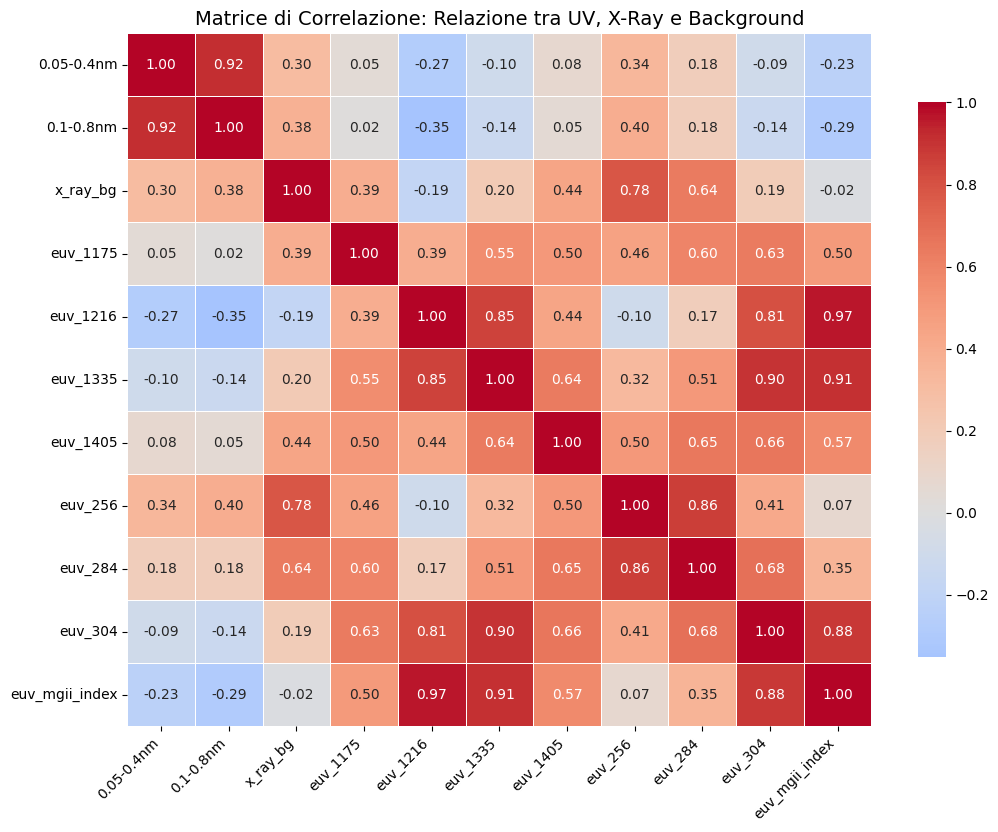

In [ ]:
.


import seaborn as sns

def plot_feature_correlation(df_sfp):
    plt.figure(figsize=(12, 9))
    
    # Pulizia: prendiamo solo colonne numeriche ed escludiamo flag tecnici
    numeric_df = df_sfp.select_dtypes(include=[np.number])
    cols_to_show = [c for c in numeric_df.columns if 'is_missing' not in c and 'satellite' not in c]
    
    corr_matrix = df_sfp[cols_to_show].corr()
    
    # Disegniamo la heatmap di correlazione
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
                fmt=".2f", linewidths=0.5, cbar_kws={"shrink": .8})
    
    plt.title("Matrice di Correlazione: Relazione tra UV, X-Ray e Background", fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.show()

plot_feature_correlation(df_sfp)

La Heatmap di correlazione di Pearson permette di validare scientificamente 
la scelta delle variabili (Feature Selection). Un coefficiente vicino a 1.0 tra 
le linee UV e il flusso X-Ray indica una forte relazione fisica. Questa ridondanza 
informativa è preziosa per il Deep Learning: se un sensore ha un calo di segnale 
o del rumore, la rete può fare affidamento sulle altre variabili correlate per mantenere
alta l'accuratezza della previsione

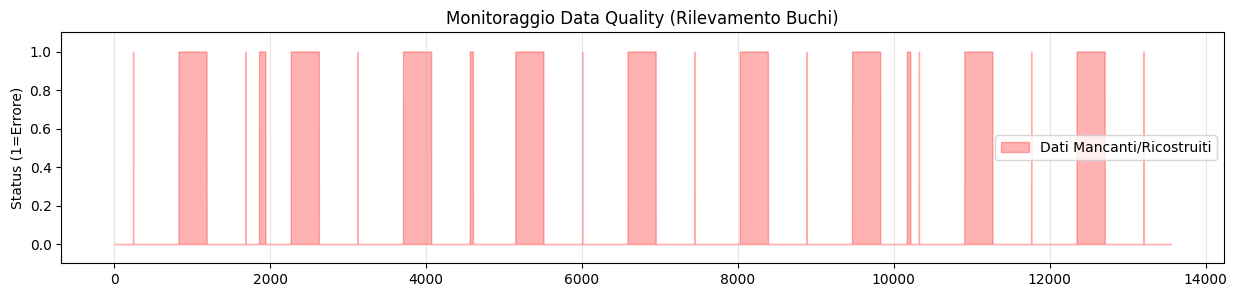

In [ ]:

def plot_data_quality(df_sfp):
    if 'euv_is_missing' in df_sfp.columns:
        plt.figure(figsize=(15, 3))
        # Determiniamo l'asse X (indice temporale)
        x_axis = df_sfp.index
        
        plt.fill_between(x_axis, 0, df_sfp['euv_is_missing'], 
                         color='red', alpha=0.3, label='Dati Mancanti/Ricostruiti')
        
        plt.title("Monitoraggio Data Quality (Rilevamento Buchi)", fontsize=12)
        plt.ylabel("Status (1=Errore)")
        plt.ylim(-0.1, 1.1)
        plt.legend()
        plt.grid(axis='x', alpha=0.3)
        plt.show()
    else:
        print("Feature 'euv_is_missing' non trovata nel dataset unificato.")

plot_data_quality(df_sfp)

Un modello di serie temporali come la LSTM è estremamente sensibile ai dati mancanti.
Questo grafico evidenzia i 'buchi' temporali rilevati durante la fase di ingestione. 
Le aree evidenziate in rosso rappresentano i punti in cui il preprocessing ha dovuto 
ricostruire il segnale (tramite interpolazione o padding). Gestire correttamente 
questi intervalli previene errori a catena durante la fase di addestramento (Training phase)

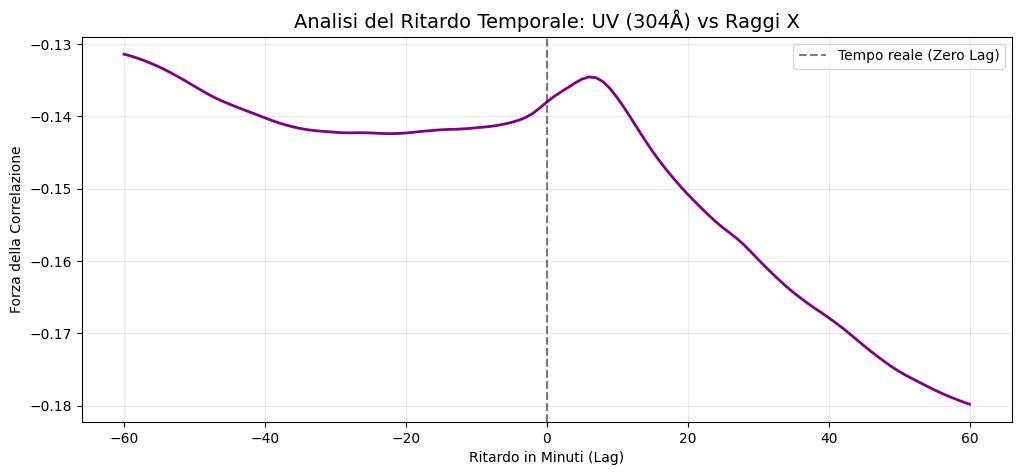

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

def plot_time_lag_correlation(df_sfp):
    # --- RIGHE MANCANTI CHE CAUSAVANO L'ERRORE ---
    # Prendiamo i valori dalle colonne del tuo dataset unificato
    # Usiamo .values per trasformarli in array numerici (numpy)
    x = df_sfp['0.1-0.8nm'].values
    y = df_sfp['euv_304'].values
    
    # 1. Normalizzazione per il calcolo statistico
    # Sottraiamo la media e dividiamo per la deviazione standard
    x_norm = (x - np.mean(x)) / (np.std(x) * len(x))
    y_norm = (y - np.mean(y)) / np.std(y)
    
    # 2. Calcolo della correlazione incrociata (Cross-Correlation)
    correlation = np.correlate(x_norm, y_norm, mode='full')
    lags = np.arange(-len(x) + 1, len(x))
    
    # 3. Visualizziamo un range di +/- 60 minuti per vedere il "ritardo"
    mask = (lags >= -60) & (lags <= 60)
    
    plt.figure(figsize=(12, 5))
    plt.plot(lags[mask], correlation[mask], color='purple', lw=2)
    
    # Linea verticale sullo zero per vedere lo sfasamento
    plt.axvline(x=0, color='black', linestyle='--', alpha=0.5, label='Tempo reale (Zero Lag)')
    
    plt.title("Analisi del Ritardo Temporale: UV (304Å) vs Raggi X", fontsize=14)
    plt.xlabel("Ritardo in Minuti (Lag)")
    plt.ylabel("Forza della Correlazione")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# Esecuzione della funzione
plot_time_lag_correlation(df_sfp)

Questo è il grafico che giustifica l'uso di una rete LSTM. Analizzando lo sfasamento (Lag)
tra i precursori UV e i Raggi X, cerchiamo la prova che un segnale anticipi l'altro. Se il picco di correlazione è spostato rispetto allo zero, abbiamo la conferma che l'UV può fornire
alla rete neurale quei minuti di preavviso necessari per una previsione efficace prima del picco 
massimo del flare.